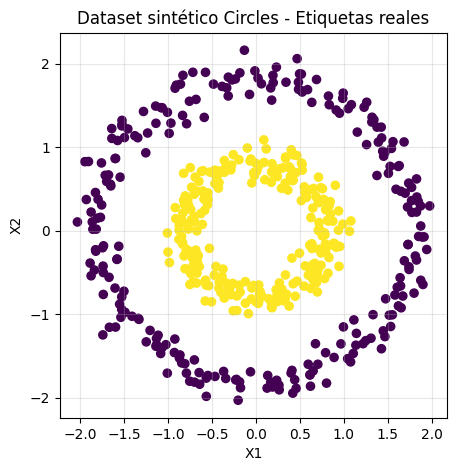

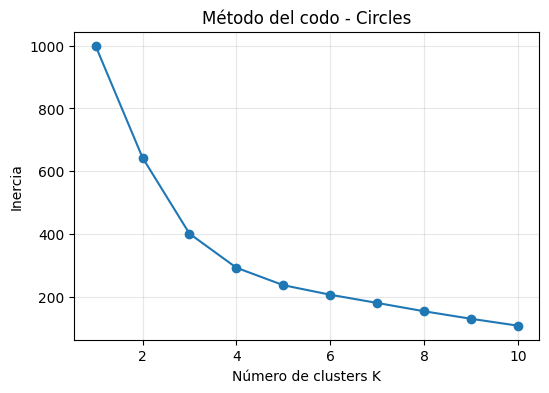

,Dataset,Modelo,ARI,V-measure,Silhouette,Davies-Bouldin,Clusters detectados,Puntos ruido
0,Circles,K-means,-0.001749,0.000185,0.342224,1.197308,2,0
1,Circles,DBSCAN,0.530220,0.497780,0.120693,1.496995,17,21
2,Circles,SpectralClustering,1.000000,1.000000,0.132900,177.617630,2,0


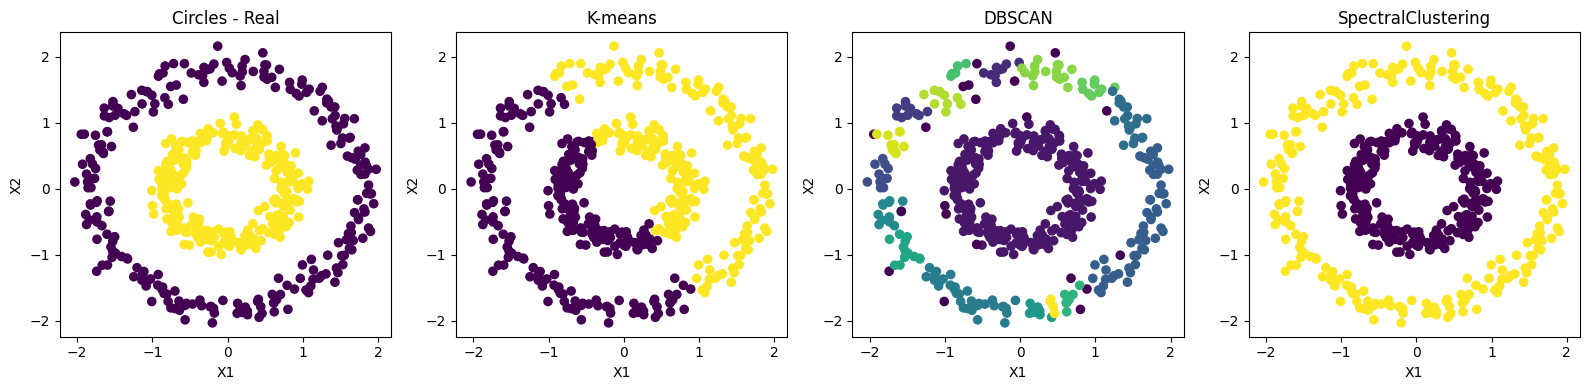

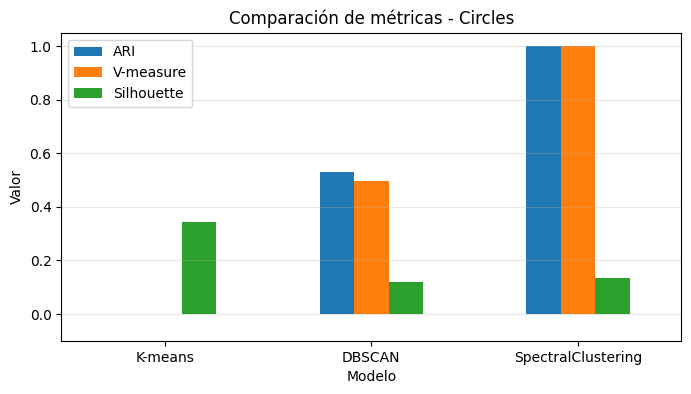

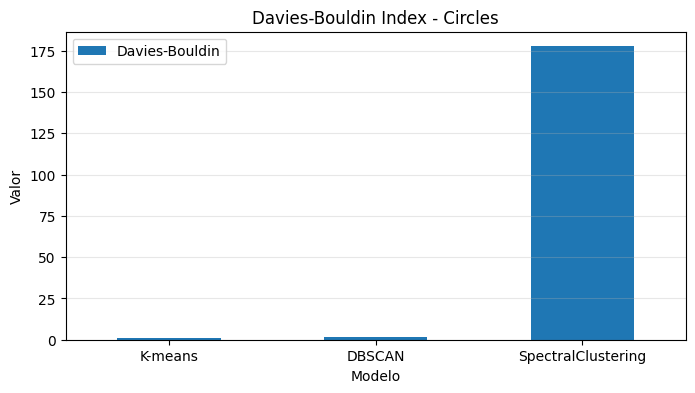

,Modelo,Naturaleza,Hiperparámetros críticos,Comportamiento en Circles
0,K-means,Lineal / basado en centroides,"n_clusters, n_init, random_state",Suele fallar porque divide los datos por cerca...
1,DBSCAN,No lineal / basado en densidad,"eps, min_samples",Puede funcionar bien si eps y min_samples capt...
2,SpectralClustering,No lineal / basado en grafos,"n_clusters, affinity, n_neighbors, assign_labels",Suele funcionar muy bien porque usa relaciones...


In [1]:
# ============================================================
# PARTE C Y D - ACTIVIDAD 04
# Dataset: Circles
# Modelos: K-means, DBSCAN, SpectralClustering
# Métricas: ARI, V-measure, Silhouette, Davies-Bouldin, Elbow
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import (
    adjusted_rand_score,
    v_measure_score,
    silhouette_score,
    davies_bouldin_score
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


# ============================================================


X, y_true = make_circles(
    n_samples=500,
    factor=0.45,
    noise=0.06,
    random_state=RANDOM_STATE
)

X_scaled = StandardScaler().fit_transform(X)


plt.figure(figsize=(5, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap="viridis", s=35)
plt.title("Dataset sintético Circles - Etiquetas reales")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(alpha=0.3)
plt.show()


# ============================================================


inercias = []
ks = range(1, 11)

for k in ks:
    modelo = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    modelo.fit(X_scaled)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(ks, inercias, marker="o")
plt.title("Método del codo - Circles")
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia")
plt.grid(alpha=0.3)
plt.show()


# ============================================================


kmeans = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_scaled)


# ============================================================


dbscan = DBSCAN(
    eps=0.18,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_scaled)


# ============================================================


spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=RANDOM_STATE
)

labels_spectral = spectral.fit_predict(X_scaled)


# ============================================================


def calcular_metricas(X, y_true, y_pred):
    ari = adjusted_rand_score(y_true, y_pred)
    v_measure = v_measure_score(y_true, y_pred)

    if len(set(y_pred)) > 1 and len(set(y_pred)) < len(X):
        silhouette = silhouette_score(X, y_pred)
        davies_bouldin = davies_bouldin_score(X, y_pred)
    else:
        silhouette = np.nan
        davies_bouldin = np.nan

    clusters_detectados = len(set(y_pred)) - (1 if -1 in y_pred else 0)
    ruido = np.sum(y_pred == -1) if -1 in y_pred else 0

    return ari, v_measure, silhouette, davies_bouldin, clusters_detectados, ruido


# ============================================================


resultados = []

modelos = {
    "K-means": labels_kmeans,
    "DBSCAN": labels_dbscan,
    "SpectralClustering": labels_spectral
}

for nombre_modelo, labels in modelos.items():
    ari, v_measure, silhouette, dbi, clusters, ruido = calcular_metricas(
        X_scaled,
        y_true,
        labels
    )

    resultados.append({
        "Dataset": "Circles",
        "Modelo": nombre_modelo,
        "ARI": ari,
        "V-measure": v_measure,
        "Silhouette": silhouette,
        "Davies-Bouldin": dbi,
        "Clusters detectados": clusters,
        "Puntos ruido": ruido
    })

df_resultados = pd.DataFrame(resultados)
display(df_resultados)


# ============================================================


plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap="viridis", s=35)
plt.title("Circles - Real")
plt.xlabel("X1")
plt.ylabel("X2")

plt.subplot(1, 4, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, cmap="viridis", s=35)
plt.title("K-means")
plt.xlabel("X1")
plt.ylabel("X2")

plt.subplot(1, 4, 3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_dbscan, cmap="viridis", s=35)
plt.title("DBSCAN")
plt.xlabel("X1")
plt.ylabel("X2")

plt.subplot(1, 4, 4)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_spectral, cmap="viridis", s=35)
plt.title("SpectralClustering")
plt.xlabel("X1")
plt.ylabel("X2")

plt.tight_layout()
plt.show()


# ============================================================


df_resultados.set_index("Modelo")[["ARI", "V-measure", "Silhouette"]].plot(
    kind="bar",
    figsize=(8, 4),
    ylim=(-0.1, 1.05)
)

plt.title("Comparación de métricas - Circles")
plt.ylabel("Valor")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.show()


df_resultados.set_index("Modelo")[["Davies-Bouldin"]].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Davies-Bouldin Index - Circles")
plt.ylabel("Valor")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.show()


# ============================================================

resumen_d = pd.DataFrame({
    "Modelo": ["K-means", "DBSCAN", "SpectralClustering"],
    "Naturaleza": [
        "Lineal / basado en centroides",
        "No lineal / basado en densidad",
        "No lineal / basado en grafos"
    ],
    "Hiperparámetros críticos": [
        "n_clusters, n_init, random_state",
        "eps, min_samples",
        "n_clusters, affinity, n_neighbors, assign_labels"
    ],
    "Comportamiento en Circles": [
        "Suele fallar porque divide los datos por cercanía a centroides y no reconoce círculos concéntricos.",
        "Puede funcionar bien si eps y min_samples capturan correctamente la densidad de cada círculo.",
        "Suele funcionar muy bien porque usa relaciones de vecindad y puede separar estructuras no lineales."
    ]
})

display(resumen_d)